In [3]:
from models.LLMs import GPT_4o, GPT_o3, Gemini
from langchain.agents import AgentExecutor, create_react_agent
from langchain.prompts import PromptTemplate
from utils.tools import Searxng
from langgraph.checkpoint.memory import MemorySaver
from typing import Literal, Annotated, List
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, add_messages
from utils.custom_output_parser import CustomOutputParser
from langgraph.prebuilt import create_react_agent
from langgraph_supervisor import create_supervisor, create_handoff_tool
import uuid, json, os
import requests, datetime, logging
from langchain_core.tools import tool
from langgraph.prebuilt import InjectedState
from langchain_core.runnables import RunnableConfig
from langgraph.types import Command
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import MessagesState, END, START
from langchain_core.messages import BaseMessage, ToolMessage, HumanMessage
from langchain_core.messages import ToolMessage
from utils.tools import image_search, web_search, crawl_url
from langfuse import Langfuse
from langfuse.callback import CallbackHandler
import pprint

OUTPUT_DIR = os.path.join(os.getcwd(), "semi_output")
GENERATED_SLIDES_DIR = os.path.join(os.getcwd(), "generated_slides")
LLM = Gemini()
LLM_o3 = GPT_o3()


langfuse = Langfuse(
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    host="https://cloud.langfuse.com"
)

langfuse_handler = CallbackHandler(
    secret_key=os.getenv("LANGFUSE_SECRET_KEY"),
    public_key=os.getenv("LANGFUSE_PUBLIC_KEY"),
    host="https://cloud.langfuse.com"
)

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s',
    handlers=[
        logging.FileHandler('workflow.log'),
        logging.StreamHandler()
    ]
)
logger = logging.getLogger(__name__)

class AgentState(TypedDict):
    messages: List[BaseMessage]
    outline: str
    images: list[dict]
    found_information: list[dict]
    input: str
    slides: list[dict]
    summary: list[dict]

members = ["outline_agent", "slide_agent", "summarizer"]
options = members + ["FINISH"]

class Router(TypedDict):
    next: Literal["outline_agent", "slide_agent", "summarizer", "FINISH"]

class Slide(TypedDict):
    slide_number: int
    summary: str
    need_enhance_visual: bool

class Summarize(TypedDict):
    slides: list[Slide]

def supervisor_node(state: AgentState) -> Command[Literal["outline_agent", "slide_agent", "summarizer", "__end__"]]:
    """
    Router function that decides which agent should run next based on the current state.
    
    Args:
        state: The current state of the workflow
        
    Returns:
        Command indicating which node to go to next
    """
    logger.info("Supervisor node: Starting workflow routing")
    logger.debug(f"Current state: {state}")
    
    if state["summary"]:
        summary = f"This is the summary of the presentation: {state['summary']}"
    else:
        summary = ""
    
    system_prompt = f"""
    You are a supervisor, tasked with managing a conversation between the following workers: {members}.
    You can respond to the user's general questions, then go to end.
    Given the user's request, respond with the worker to act next. 
    {summary}
    If there is outline, you should go to slide_agent to generate the slides.
    If there is slide_summary, you should decide whether or not enhance slides, and which slides need to be enhanced, otherwise go to FINISH.
    Each worker will perform a task and respond with results and status. 
    When finished creating slides, go to FINISH.
    
    Respond with ONLY one of these options: outline_agent, slide_agent, summarizer, or FINISH
    """
    messages = [{"role": "system", "content": system_prompt}] + state["messages"]
    response = LLM.invoke(messages, config=config)
    goto = response.content.strip()
    
    if goto not in options:
        logger.warning(f"Invalid response from supervisor: {goto}")
        goto = "outline_agent"  # Default to outline_agent if invalid response
        
    if goto == "FINISH":
        goto = END
    logger.info(f"Supervisor node: Routing to {goto}")
    return Command(goto=goto, update={"next": goto})

def outline_agent_node(state: AgentState) -> Command[Literal["supervisor"]]:
    """
    Agent that generates the presentation outline.
    
    Args:
        state: The current state of the workflow
        
    Returns:
        Command to update the state and proceed to supervisor
    """
    logger.info("Outline agent: Starting outline generation")
    logger.debug(f"Input state: {state}")
    
    prompt = """You are a research assistant helping to create a presentation. Follow these steps:

    1. First, use web_search to gather information about the topic
    2. Then, use crawl_url to get detailed information from specific websites
    3. Use image_search to find relevant images
    4. Finally, Generate full presentation content follow the user instructions
    
    The presentation content should contains these slide:
    - Cover slide
    - Table of contents
    - Introduction slide
    - Main content slides
    - Key points slides
    - Graphs and charts slides
    - Conclusion slide
    - Reference slide
    
    IMPORTANT: You MUST use at least web_search, crawl_url and image_search before generating the outline.
    """
    
    outline_agent = create_react_agent(
        model=LLM,
        tools=[image_search, crawl_url, web_search],
        prompt=prompt
    )
    logger.info("Outline agent: Created agent with tools")
    
    result = outline_agent.invoke(state, config=config)
    logger.info("Outline agent: Completed outline generation")
    
    # Extract tool outputs from messages
    outline = result
    images = []
    found_info = []
    
    # Handle potential missing 'messages' key in result
    try:
        messages_list = result.get("messages", [])
        if not messages_list and hasattr(result, "messages"):
            messages_list = result.messages
    except (AttributeError, TypeError):
        logger.warning(f"Unexpected result format: {type(result)}")
        messages_list = []
        if isinstance(result, list):
            messages_list = result
    
    last_message_content = "Outline generation completed"
    
    for message in messages_list:
        if isinstance(message, ToolMessage):
            logger.debug(f"Processing tool message: {message.name}")
            try:
                content = json.loads(message.content)
                
                if message.name == "image_search":
                    if isinstance(content, dict) and "results" in content:
                        images.extend(content["results"])
                        logger.info(f"Found {len(content['results'])} images")
                    else:
                        images.append({"url": message.content})
                        logger.info("Found 1 image")
                elif message.name in ["web_search", "crawl_url"]:
                    if isinstance(content, dict):
                        # Handle the case where content has results array (typical web_search format)
                        if "results" in content and isinstance(content["results"], list):
                            for result in content["results"]:
                                found_info.append({
                                    "source": message.name,
                                    "content": result.get("content", ""),
                                    "title": result.get("title", "")
                                })
                            logger.info(f"Found {len(content['results'])} results from {message.name}")
                        else:
                            found_info.append({
                                "source": message.name,
                                "content": content.get("content", ""),
                                "title": content.get("title", "")
                            })
                            logger.info(f"Found information from {message.name}")
                    else:
                        found_info.append({
                            "source": message.name,
                            "content": message.content,
                        })
                        logger.info(f"Found information from {message.name}")
                        
            except json.JSONDecodeError:
                logger.warning(f"Failed to parse JSON from {message.name}")
                if message.name == "image_search":
                    images.append({"url": message.content})
                    logger.info("Found 1 image (plain text)")
                elif message.name in ["web_search", "crawl_url"]:
                    found_info.append({
                        "source": message.name,
                        "content": message.content,
                    })
                    logger.info(f"Found information from {message.name} (plain text)")
        
        # Save the last message content for the return
        if hasattr(message, "content"):
            last_message_content = message.content
            
    logger.info(f"Outline agent: Outline: {outline}")
    logger.info(f"Outline agent: Completed with {len(images)} images and {len(found_info)} information sources")
    return Command(
        update={
            "messages": [HumanMessage(content=last_message_content, name="outline_agent")],
            "outline": outline,
            "images": images,
            "found_information": found_info
        },
        goto="supervisor"
    )
    
def slide_agent_node(state: AgentState) -> Command[Literal["supervisor"]]:
    """
    Agent that generates the presentation slides.
    
    Args:
        state: The current state of the workflow
        
    Returns:
        Command to update the state and proceed to supervisor
    """
    logger.info("Slide agent: Starting slide generation")
    logger.info(f"Input state: {state}")
    
    images = state["images"]
    found_info = state["found_information"]
    
    logger.info(f"Images: {images}")
    logger.info(f"Found information: {found_info}")
    
    @tool
    def generate_slide(slide_number: int, instructions: str, images_url: str, style: str, color_scheme: str, design_language: str) -> str:
        """
        Generate a single HTML slide and save it to the file system.
        
        Args:
            slide_number: The number of the slide to generate
            instructions: The instructions for the slide content
        Returns:
            String with information about the generated slide
        """
        try:
            # Get the state from a global variable or pass it through context
            # Instead of trying to inject it directly
            logger.info(f"Instructions: {instructions}")
            logger.info(f"Images url: {images_url}")
            logger.info(f"Style: {style}")
            logger.info(f"Color scheme: {color_scheme}")
            logger.info(f"Design language: {design_language}")
            
            with open("rules/html.txt", "r") as f:
                html_rules = f.read()
                
            presentation_prompt = f"""
            You are a professional presentation designer.
            
            This is the html example for the slides, consider this length and layout, other content as example only, you can ignore this: {html_rules}
                                    
            This is the list of information that you can use for the slides: {found_info}
                        
            This is the image url that need to use for the slides: {images_url}
            
            This is the style of the slide: {style}
            
            This is the color scheme of the slide: {color_scheme}
            
            This is the design language of the slide: {design_language}
            
            The slide should follow these instructions: {instructions}
            
            Create slide presentation with tailwind css for artiristic slides, with color scheme and design language inspired from the topic.
            Make the slide in details, with a lot of information.
            IMPORTANT:
            The slide should be generate with: width: 1280px; min-height: 720px; position: relative; overflow: hidden;
            All elements should be wrap in a div, or section that split the slide into multiple sections.
            
            
            IMPORTANT: Always using Google Font, Tailwind CSS, Font Awesome icons to add-on
            Using chart.js if needed
            Image should be wrap in section, should be in a appropriate scale, that's not too big or too small, and not too wide or too narrow.
            If the content is short, make it 1 column and in appropriate scale, if the content is long, make it multiple columns.
            Make the slide responsive, big font size and bold if need to be highlighted.
            Make the slide look like a professional presentation.
            As many generate token as possible.
            
            IMPORTANT: Make sure the slide is in 1280x720px size.
            IMPORTANT: Background should be solid color, never use hero image.
            """
            
            # Get the response and extract the content
            response = LLM_o3.invoke(presentation_prompt, config=config)
            html_content = response.content if hasattr(response, 'content') else str(response)
            
            # Extract only the HTML content between <!DOCTYPE html> and </html>
            start_marker = "<!DOCTYPE html>"
            end_marker = "</html>"
            start_idx = html_content.find(start_marker)
            end_idx = html_content.find(end_marker)
            
            if start_idx != -1 and end_idx != -1:
                html_content = html_content[start_idx:end_idx + len(end_marker)]
            else:
                logger.warning("Could not find proper HTML markers in the response")
            
            # Save individual slide
            os.makedirs(GENERATED_SLIDES_DIR, exist_ok=True)
            output_path = os.path.join(GENERATED_SLIDES_DIR, f"slide_{slide_number:03d}.html")
            with open(output_path, "w", encoding="utf-8") as f:
                f.write(html_content)
                
            return f"Slide #{slide_number} generated successfully. Saved to {output_path}"
        except Exception as e:
            logger.error(f"Failed to generate slide: {str(e)}")
            return f"Failed to generate slide: {str(e)}"
    
    with open("rules/instruction.txt", "r") as f:
        instruction = f.read()
        
    prompt = f"""You are a presentation slide generator. Your task is to create slides based on the outline.
    
    This is list of images that you can use for the slides: {images}
    This is the list of information that you can use for the slides: {found_info}
    This is the instructions for the slides: {instruction}
    
    Strategy:
    1. First think about design style, color scheme, and design language that inspired from the topic.
    2. Think about how to display the slide, giving details description, send the tool as more as information as possible.
    2. Use the generate_slide tool to generate the slide
    3. Repeat until all slides are generated
    
    Remember to generate enough slides follow user instructions.
    
    
    
    For each slide:
    1. Use the generate_slide tool with appropriate parameters
    2. Include relevant images from the found images if available
    3. Use a consistent style and color scheme (Giving at least 7 color scheme in name, not in hex code)
    4. Each slide should be in various way and layout and not similar to each other
    5. Make the slide in details, with a lot of information.
    6. Make the slide responsive, big font size and bold if need to be highlighted.
    7. Make the slide background in details way, with many small elements or Font Awesome icons to add on.

    IMPORTANT: Generate slides one at a time, starting with slide 1.
    """
    
    # Use the enhanced tool instead of the original one
    slide_agent = create_react_agent(
        model=LLM_o3,
        tools=[generate_slide],
        prompt=prompt
    )
    logger.info("Slide agent: Created agent with tools")
    
    try:
        result = slide_agent.invoke(state, config=config)
        logger.info(f"Slide agent: {result}")
        logger.info("Slide agent: Completed slide generation")
        
        slides = []
        
        # Handle potential missing 'messages' key in result
        try:
            messages_list = result.get("messages", [])
            if not messages_list and hasattr(result, "messages"):
                messages_list = result.messages
        except (AttributeError, TypeError):
            logger.warning(f"Unexpected result format: {type(result)}")
            messages_list = []
            if isinstance(result, list):
                messages_list = result
        
        last_message_content = "Slide generation completed"
        
        for message in messages_list:
            if isinstance(message, ToolMessage):
                if message.name in ["enhanced_generate_slide", "generate_slide"]:
                    try:
                        slide_number = message.additional_kwargs.get("slide_number", 0)
                        if not slide_number and "Slide #" in message.content:
                            import re
                            match = re.search(r"Slide #(\d+)", message.content)
                            if match:
                                slide_number = int(match.group(1))
                        
                        slides.append({
                            "content": message.content,
                            "slide_number": slide_number,
                        })
                        logger.info(f"Generated slide #{slide_number}")
                    except Exception as e:
                        logger.error(f"Error processing slide: {str(e)}")
                        slides.append({
                            "content": message.content,
                            "error": str(e),
                        })
            
            # Save the last message content for the return
            if hasattr(message, "content"):
                last_message_content = message.content
        
        logger.info(f"Slide agent: Generated {len(slides)} slides")
        return Command(
            update={
                "messages": [HumanMessage(content=last_message_content, name="slide_agent")],
                "slides": slides
            },
            goto="supervisor"
        )
    except Exception as e:
        logger.error(f"Error in slide generation: {str(e)}")
        return Command(
            update={
                "messages": [HumanMessage(content=f"Error generating slides: {str(e)}", name="slide_agent")],
                "slides": []
            },
            goto="supervisor"
        )
        
def summarizer_node(state: AgentState) -> Command[Literal["supervisor"]]:
    """
    Agent that summarizes the presentation slides.
    
    Args:
        state: The current state of the workflow
    """
    logger.info("Summarizer: Starting slide summarization")
    logger.debug(f"Input state: {state}")
    
    slides = state["slides"]
    prompt = f"""
    You are a summarizer, tasked with summarizing the presentation slides.
    
    This is the list of slides: {slides}
    
    For each slide, analyze if it needs visual enhancement and provide a brief summary.
    Format your response as follows for each slide:
    Slide [number]: [brief summary] - [Needs visual enhancement/Visuals are good]
    
    Example format:
    Slide 1: Introduction to the topic - Visuals are good
    Slide 2: Key concepts overview - Needs visual enhancement
    """
    response = LLM.invoke(prompt, config=config)
    logger.info("Summarizer: Completed slide analysis")
    
    summary_text = response.content.strip()
    logger.info("Summarizer: Completed all slide summaries")
    
    return Command(
        update={
            "messages": [HumanMessage(content=summary_text, name="summarizer")],
            "summary": summary_text
        },
        goto="supervisor"
    )


graph = StateGraph(AgentState)
graph.add_node("supervisor", supervisor_node)
graph.add_node("outline_agent", outline_agent_node)
graph.add_node("slide_agent", slide_agent_node)
graph.add_node("summarizer", summarizer_node)
graph.add_edge(START, "supervisor")

app = graph.compile()

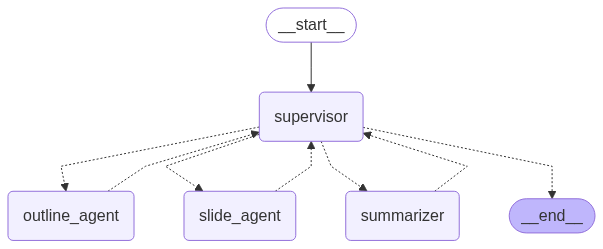

In [4]:
from IPython.display import display, Image

display(Image(app.get_graph().draw_mermaid_png()))
